In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from run_evolution import folder_evol
from analytical_results import fT00, fT01, fT11, fj0, fj1, fnu, fLn

from sklearn.decomposition import PCA
from scipy.special import jv, gammaincc, gamma
from scipy.optimize import minimize

save = False

In [56]:
g = 1
v = 1
Q = 1
dt = 1 / 16
tol = 1e-6
method = '12site'
mlat = True

data = {}
ms = [0.0, 0.1, 0.2, 0.3183, 0.4, 0.5, 0.6, 0.7]
for m in ms:
    for (N, a) in [(512, 1/8), (1024, 1 / 16)]:
        for D in [128, 256]:
            folder = folder_evol(g, m, a, N, v, Q, D, dt, D, tol, method, mlat, mkdir=False)
            try:
                d = np.load(folder / f"results.npy", allow_pickle=True).item()
                data[m, N, a, D] = d
            except FileNotFoundError:
                pass

# labels for projections on 1 and 2 bonds
E1s = np.array([-3, -2, -1, 0, 1, 2, 3]) - 1  # -1 to take into account left-moving charge
E2s = np.array([-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]) / 2 - 1  # -1 to take into account left-moving charge

#  initial time for fitting
t0 = 1.5
#
# parameters for fit
N, a, D = 1024, 0.0625, 256


In [57]:
# calculated quantities
for x in sorted(data[0.5, 512, 1/8, 128].keys()):
    print(x)

Ln
T00
T01
T11
energy
ent1a
ent1b
ent1c
ent2a
ent2b
entropy_1
entropy_2
entropy_3
evol_time
j0
j1
min_Schmidt
nu
pr11
pr1a
pr1b
pr1c
pr2
time


m=0.50, eps_string=0.943420, bLkappa2=0.028070   Optimization terminated successfully.
m=0.60, eps_string=0.909695, bLkappa2=0.014338   Optimization terminated successfully.
m=0.70, eps_string=0.884854, bLkappa2=0.006230   Optimization terminated successfully.


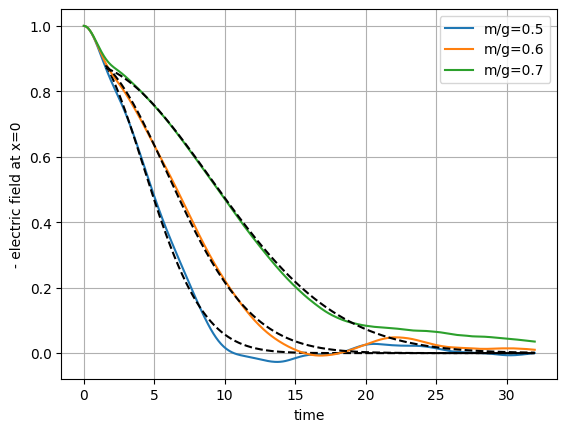

In [62]:
# Fig 2a

mfits = []
bkappa2_Ln = []

for m in [0.5, 0.6, 0.7]:
    d = data[m, N, a, D]
    time = d['time']
    Ln = ((d['pr1b'] + d['pr1c']) / 2) @ E1s
    plt.plot(time, -Ln, label=f"{m/g=:0.1f}")

    slc = time > t0
    x = time[slc]
    y = Ln[slc]

    def f(b, al, tau):
        return gammaincc(1+al, b*tau**2)

    def mse(pars):
        eps_string, bLkappa2 = pars
        return np.mean((y + eps_string * f(bLkappa2, 0, x)) ** 2)

    x0 = (0.9, np.exp(-2.2 - 6 * m * m))
    sol = minimize(mse, x0)
    eps_string, bLkappa2 = sol.x

    mfits.append(m)
    bkappa2_Ln.append(bLkappa2)

    print(f"{m=:0.2f}, {eps_string=:0.6f}, {bLkappa2=:0.6f}   {sol.message}")

    plt.plot(x, eps_string * f(bLkappa2, 0, x), '--k')

    plt.xlabel('time')
    plt.ylabel('- electric field at x=0')
    plt.grid()
    plt.legend()


Text(0, 0.5, 'log b kappa**2')

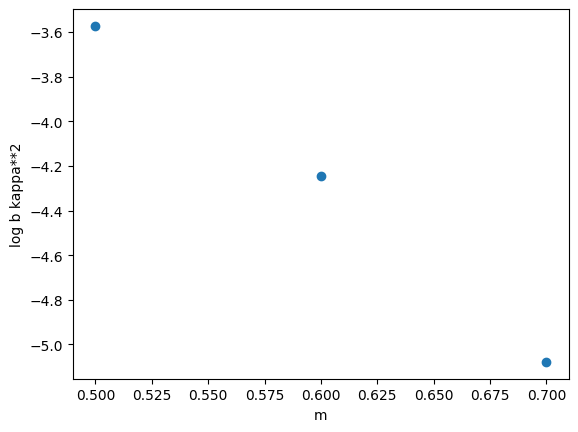

In [63]:
# Fig 2b
N, a, D = 1024, 0.0625, 256

plt.plot(mfits, np.log(bkappa2_Ln), 'o')
plt.xlabel("m")
plt.ylabel("log b kappa**2")


m=0.50, eps_string=0.768227, bLkappa2=0.026172 const=0.09888  Desired error not necessarily achieved due to precision loss.
m=0.60, eps_string=0.755491, bLkappa2=0.013561 const=0.15241  Desired error not necessarily achieved due to precision loss.
m=0.70, eps_string=0.749086, bLkappa2=0.006586 const=0.23154  Desired error not necessarily achieved due to precision loss.


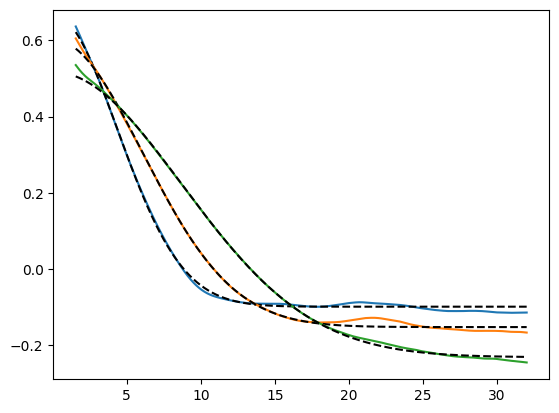

In [ ]:
# Fig 2c

mfits = []
bkappa2_prob = []

for m in [0.5, 0.6, 0.7]:
    d = data[m, N, a, D]
    time = d['time']

    slc = time > t0
    x = time[slc]

    prob_mid = (d['pr1b'] + d['pr1c']) / 2
    prob_mid = prob_mid[slc]
    pcaproj = PCA(n_components=1)
    pcaproj.fit(prob_mid)
    y = pcaproj.transform(prob_mid).ravel()

    plt.plot(x, y, label=f"{m/g=:0.2f}")

    def f(b, al, tau):
        return gammaincc(1 + al, b * tau ** 2)

    def mse_prob(pars):
        eps_string, bLkappa2, const = pars
        return np.mean(np.abs((y + const - eps_string * f(bLkappa2, 0, x))))

    x0 = (0.75, np.exp(-2.2 - 6 * m * m),  0.64 * m - 0.23)
    sol = minimize(mse_prob, x0)
    eps_string, bLkappa2, const = sol.x
    print(f"{m=:0.2f}, {eps_string=:0.6f}, {bLkappa2=:0.6f} {const=:0.5f}  {sol.message}")
    plt.plot(x, eps_string * f(bLkappa2, 0, x) - const, '--k')

    mfits.append(m)
    bkappa2_prob.append(bLkappa2)


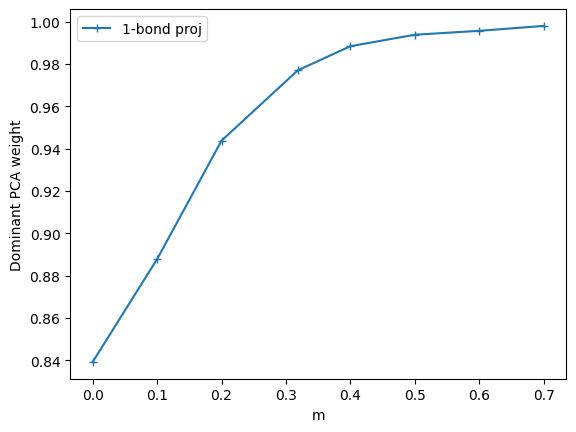

In [104]:
# Fig 3a

pca = PCA()

dom = []
for m in ms:
    d = data[m, N, a, D]
    time = d['time']
    probs = ((d['pr1b'] + d['pr1c']) / 2)

    slc = time > 0
    x = time[slc]
    probs = probs[slc]

    pca.fit(probs)
    y = pca.explained_variance_ratio_[0]
    dom.append(y)
plt.plot(ms, dom, '-+', label=f"1-bond proj")

plt.xlabel("m")
plt.ylabel("Dominant PCA weight")
plt.legend()


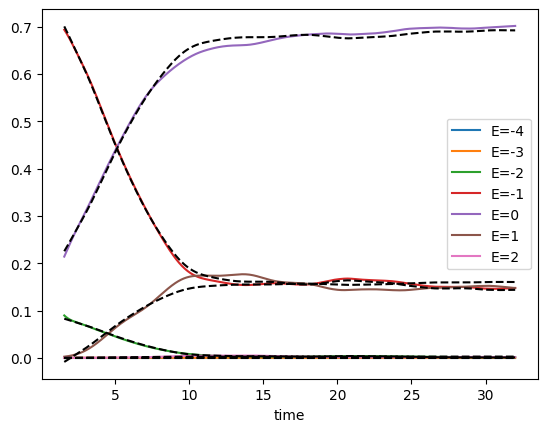

In [121]:
# Fig 3b

pca = PCA(n_components=1)

dom = []
m = 0.5

d = data[m, N, a, D]
time = d['time']
probs = ((d['pr1b'] + d['pr1c']) / 2)

slc = time > t0
x = time[slc]
probs = probs[slc]

pca.fit(probs)
y = pca.transform(probs)
cc = pca.components_

for ii, EE in enumerate(E1s):
    plt.plot(x, probs[:, ii], label=f"E={EE:1d}")

reconstruct = y @ cc + np.mean(probs, axis=0)
plt.plot(x, reconstruct, '--k')


plt.xlabel("time")
plt.ylabel("")
plt.legend()


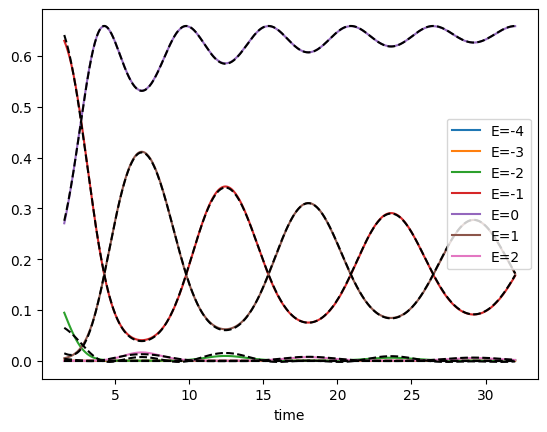

In [125]:
# Fig 3c

pca = PCA(n_components=2)

dom = []
m = 0.0

d = data[m, N, a, D]
time = d['time']
probs = ((d['pr1b'] + d['pr1c']) / 2)

slc = time > t0
x = time[slc]
probs = probs[slc]

pca.fit(probs)
y = pca.transform(probs)
cc = pca.components_

for ii, EE in enumerate(E1s):
    plt.plot(x, probs[:, ii], label=f"E={EE:1d}")

reconstruct = y @ cc + np.mean(probs, axis=0)
plt.plot(x, reconstruct, '--k')


plt.xlabel("time")
plt.ylabel("")
plt.legend()


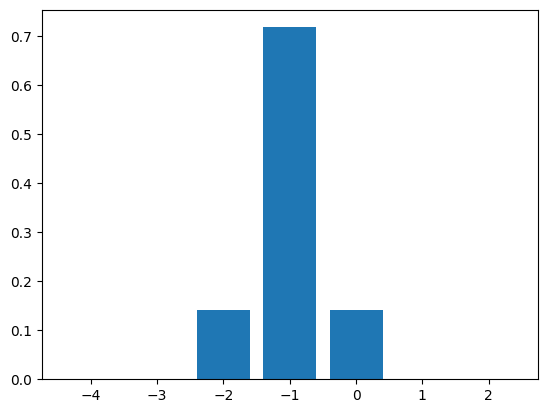

<BarContainer object of 7 artists>

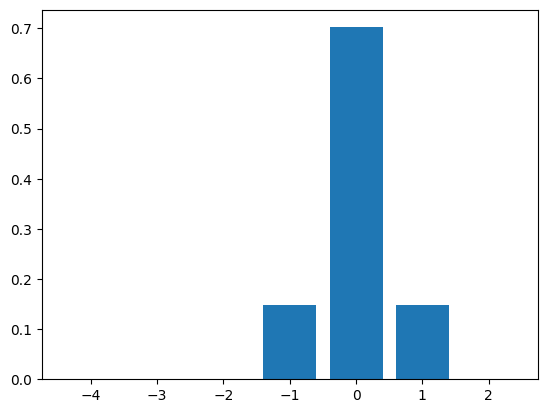

In [ ]:
# Fig 4a
m = 0.5
d = data[m, N, a, D]

time = d['time']
prob_mid = (d['pr1b'] + d['pr1c']) / 2
ind = np.argmin(abs(time - 0))
plt.bar(E1s, prob_mid[ind][:])
plt.show()
plt.bar(E1s, prob_mid[-1][:])


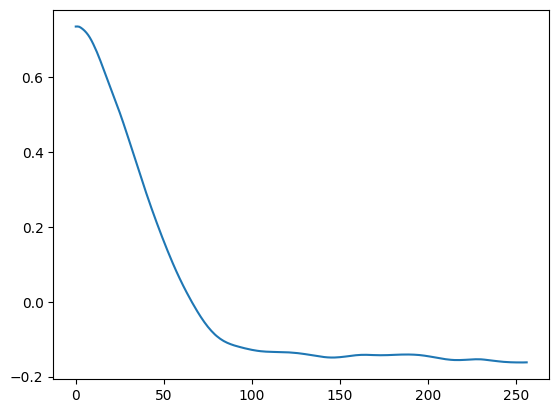

In [24]:
plt.plot(pcacomp)

In [ ]:
def dominant_component(ax, m,  D):
    pls_mid = get_probability(m, D)
    pcaproj = PCA(n_components=1)
    pcaproj.fit(pls_mid[slc])
    pcacomp = pcaproj.transform(pls_mid[slc])


    def f(b, al, tau):
        return gammaincc(1+al, b*tau**2)

    y = pcacomp[:, 0]
    t = ts[slc]

    def mse(pars):
        c, b, a = pars
        return np.mean((y + a - c * f(b, 0, t)) ** 2)

    x0 = (0.57, 0.06, 0.1)
    sol = minimize(mse, x0)

    c, b, a = sol.x

    ax.plot(t, pcacomp, 'o-', alpha=0.5, label='first PCA component')
    tf = np.linspace(0, ts[-1], 500)
    ax.plot(tf, c * f(b, 0, tf) - a, label='Lund-like gaussian fit')
    ax.grid()
    ax.legend()
    ax.set_xlabel('t')
    ax.set_ylabel('f(t)')
    ax.set_xlim(0, ts[-1])
    ax.set_ylim(-1, 1)
    ax.set_title(f"{m/g=}")
    ax.text(ts[-1] /2, 0.6, f"{a=:0.3f} {b=:0.3f} {c=:0.3f}")